In [1]:
from package_novqs import *

E0918 03:42:39.323048 1703173 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )
E0918 03:42:39.334702 1703063 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )


JAX device: [CudaDevice(id=0)]


# Model

## H_n Chain

In [2]:
n_atoms = 5  # N_q = 10
n_orbits = n_atoms
n_electrons = n_atoms

model_name = f"H{n_atoms}Chain"
distance = 2.0

geometry = [
    ("H", (0.0, 0.0, i * distance))
    for i in range(n_atoms)
]

multiplicity = 1 if n_atoms % 2 == 0 else 2

molecule = MolecularData(
    geometry=geometry,
    basis="sto-3g",
    multiplicity=multiplicity,
    charge=0,
    data_directory=os.path.join(os.getcwd(), "data"),
)

molecule = run_pyscf(molecule)

second_q_hamiltonian = molecule.get_molecular_hamiltonian()
jw_hamiltonian = jordan_wigner(second_q_hamiltonian)
Ham = qml.import_operator(jw_hamiltonian)

H_mat = qml.matrix(Ham)
eigvals, eigvecs = jnp.linalg.eigh(H_mat)
Eg = eigvals[0]

# Ansatz

In [52]:
# 1. Instantiate the ansatz object
Nq = n_orbits * 2
n_blocks = 4   # Adjust manually
n_layers = Nq // 2
ansatz = fSimAnsatz(Nq, n_blocks, n_layers)

# 2. Create the device and circuit
dev = qml.device("default.qubit", wires=Nq)
hf_state = qml.qchem.hf_state(n_electrons, Nq)
init_state = 'HF' # uniform superposition state (US), Hartree Fock state (HF)
init_dist = 'Perturbation'  # Gaussian, Uniform, Zeros, Perturbation
circuit = get_circuit(dev, ansatz, init_state, hf_state)
circuits_fn = jax.jit(jax.vmap(circuit, in_axes=(0,)))   # for multi ansatze

# 3. Initialize the parameters and run
print("--- Quantum circuit diagram ---")
params = init_params(Nq, n_blocks, n_layers, Ns=1, method=init_dist, seed=0)
print(qml.draw(circuit)(params))

--- Quantum circuit diagram ---
0: ─╭|Ψ⟩─╭IsingXY(-0.02)─╭●─────────╭SWAP──────────────────────────────────╭IsingXY(-0.02) ···
1: ─├|Ψ⟩─╰IsingXY(-0.02)─╰Rϕ(-0.04)─╰SWAP─╭IsingXY(0.09)──╭●─────────╭SWAP─╰IsingXY(-0.02) ···
2: ─├|Ψ⟩─╭IsingXY(0.12)──╭●─────────╭SWAP─╰IsingXY(0.09)──╰Rϕ(-0.06)─╰SWAP─╭IsingXY(0.01)─ ···
3: ─├|Ψ⟩─╰IsingXY(0.12)──╰Rϕ(0.01)──╰SWAP─╭IsingXY(0.04)──╭●─────────╭SWAP─╰IsingXY(0.01)─ ···
4: ─├|Ψ⟩─╭IsingXY(0.01)──╭●─────────╭SWAP─╰IsingXY(0.04)──╰Rϕ(0.06)──╰SWAP─╭IsingXY(0.02)─ ···
5: ─├|Ψ⟩─╰IsingXY(0.01)──╰Rϕ(-0.02)─╰SWAP─╭IsingXY(0.03)──╭●─────────╭SWAP─╰IsingXY(0.02)─ ···
6: ─├|Ψ⟩─╭IsingXY(0.10)──╭●─────────╭SWAP─╰IsingXY(0.03)──╰Rϕ(-0.01)─╰SWAP─╭IsingXY(-0.11) ···
7: ─├|Ψ⟩─╰IsingXY(0.10)──╰Rϕ(0.02)──╰SWAP─╭IsingXY(-0.05)─╭●─────────╭SWAP─╰IsingXY(-0.11) ···
8: ─├|Ψ⟩─╭IsingXY(0.01)──╭●─────────╭SWAP─╰IsingXY(-0.05)─╰Rϕ(0.02)──╰SWAP─╭IsingXY(0.09)─ ···
9: ─╰|Ψ⟩─╰IsingXY(0.01)──╰Rϕ(-0.04)─╰SWAP──────────────────────────────────╰IsingXY(0.09)─ ···

0: ··· ─╭●───────

# VQS

In [16]:
# 3. Perform one evolution step (e.g., imaginary-time evolution)
params = init_params(Nq, n_blocks, n_layers, Ns=1, method=init_dist, seed=0)

# 2. Initialize the evolution solver
# H_mat is the previously generated Hamiltonian matrix
evolver = VariationalEvolver(circuit, H_mat, reg=1e-8)

psi0 = circuit(params)  # hf_state because params are set to 0s
eig_coeffs = eigvecs.conj().T @ psi0
#print(jnp.abs(eig_coeffs)**2)

In [17]:
# Simulation parameters
T = 5.0
dt = 0.005
n_steps = int(T / dt)

time_points = jnp.zeros(n_steps + 1)
trajectory = jnp.zeros((len(params), n_steps + 1))

time_points = time_points.at[0].set(0.0)
trajectory = trajectory.at[:, 0].set(params)


# Time-stepping loop
for i in tqdm(range(n_steps), desc="Real Time Evolution"):
    t = i * dt
    params = rk4_step(evolver.theta_dot_rte, t, params, dt) # Only this step is accelerated

    time_points = time_points.at[i + 1].set(t + dt)    # Time points
    trajectory = trajectory.at[:, i + 1].set(params)   # Parameter trajectory shape=(n_params, n_time_points)

Real Time Evolution: 100%|██████████| 1000/1000 [16:21<00:00,  1.02it/s]


## Fidelity

In [18]:
# 2. Instantiate exactRTE
rte_solver = exactRTE(eigvals, eigvecs, eig_coeffs)

# 3. Instantiate FidelityCalculator and pass in solver
fid_calc = FidelityCalculator(circuit, rte_solver)

# 4. Batched calculation
# Note: if trajectory has shape (n_params, steps), transpose it to (steps, n_params)
params_all = trajectory.T
fidelities_vqs = fid_calc.compute_batched(params_all, time_points, batch_size=100)

Computing Fidelity: 100%|██████████| 11/11 [00:26<00:00,  2.38s/it]


## Save data

In [19]:
if not os.path.exists("data"):
    os.makedirs("data")

file_path = f"data/VQS-RTE-fidelities-{model_name}-dist={distance}-Nq={Nq}-T={T}-dt={dt}-L={n_layers}-B={n_blocks}-{init_state}-{init_dist}.npy"

data_to_save = {
    "fidelities": fidelities_vqs,
    "time_points": time_points  
}
jnp.save(file_path, data_to_save)

0.796942373142669


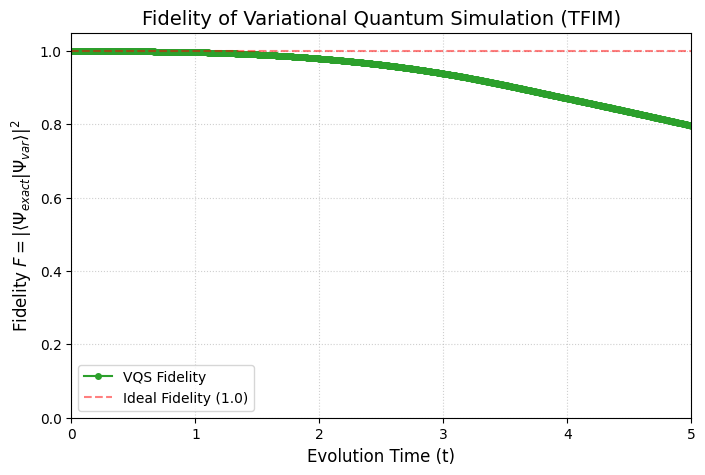

In [20]:
import matplotlib.pyplot as plt

def plot_fidelity(time_points, fidelities):
    plt.figure(figsize=(8, 5), dpi=100)
    
    # Plot the fidelity curve
    plt.plot(time_points, fidelities, 'o-', color='#2ca02c', label='VQS Fidelity', markersize=4)
    
    # Plot the ideal reference line (Fidelity = 1)
    plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Ideal Fidelity (1.0)')
    
    # Set the axis limits
    plt.ylim(0, 1.05)  # Extend slightly above 1.0 to keep the topmost points visible
    plt.xlim(time_points[0], time_points[-1])
    
    # Add axis labels and a title
    plt.xlabel('Evolution Time (t)', fontsize=12)
    plt.ylabel('Fidelity $F = |\\langle \\Psi_{exact} | \\Psi_{var} \\rangle|^2$', fontsize=12)
    plt.title('Fidelity of Variational Quantum Simulation (TFIM)', fontsize=14)
    
    plt.grid(True, which='both', linestyle=':', alpha=0.6)
    plt.legend(loc='lower left')
    
    plt.show()

# Call the plotting function
print(fidelities_vqs[-1])
plot_fidelity(time_points, fidelities_vqs)

# NOVQS

In [53]:
# Parameters
Ns = 2
params = init_params(Nq, n_blocks, n_layers, Ns, method=init_dist, seed=0)

coeffs_a = jnp.ones((Ns,))  # ones  zeros
coeffs_a = coeffs_a.at[0].set(1.0)
coeffs_b = jnp.zeros((Ns,)) 
coeffs_init = coeffs_a * jnp.exp(1j * coeffs_b)
params_coeffs = jnp.concatenate([params, coeffs_a, coeffs_b])  # (n_params + Ns * 2,)

# 1. Instantiate
evolver = MultiStateEvolver(circuit, eigvals, eigvecs, Nq, Ns, reg=1e-8)


states = circuits_fn(params.reshape(Ns, -1))  # (Ns, dim)
psi0 = coeffs_init @ states         # (dim,)
norm = jnp.linalg.norm(psi0)
psi0 = psi0 / norm
eig_coeffs = eigvecs.conj().T @ psi0
print(jnp.abs(eig_coeffs)**2)

[6.24137854e-04 3.48351110e-01 1.96911478e-03 ... 1.94139039e-34
 2.97402853e-35 0.00000000e+00]


In [54]:
# Simulation parameters
T = 5.0
dt = 0.005
steps = int(T / dt)

time_points = jnp.zeros(steps + 1)
trajectory = jnp.zeros((len(params_coeffs), steps + 1))  

time_points = time_points.at[0].set(0.0)
trajectory = trajectory.at[:, 0].set(params_coeffs)

# Time-stepping loop
for i in tqdm(range(steps), desc="Real Time Evolution"):

    t = i * dt
    params_coeffs = rk4_step(evolver.theta_dot_rte, t, params_coeffs, dt) 

    time_points = time_points.at[i + 1].set(t + dt)           # Time points
    trajectory = trajectory.at[:, i + 1].set(params_coeffs)   # Parameter trajectory shape=(n_params_coeffs, n_time_points)

Real Time Evolution: 100%|██████████| 1000/1000 [32:39<00:00,  1.96s/it]


## Fidelity

In [55]:
# 1. Set up the exact solver
rte_solver = exactRTE(eigvals, eigvecs, eig_coeffs)

# 2. Instantiate the fidelity calculator (assuming Ns=2)
fid_calc = MultiStateFidelityCalculator(circuit, rte_solver, Ns)

# 3. Batched calculation
# Assume trajectory has shape (Total_params, steps)
# Pass the transposed array so each row represents one time step
params_all = trajectory.T
fidelities_novqs = fid_calc.compute_batched(params_all, time_points, batch_size=100)


Computing Fidelity: 100%|██████████| 11/11 [00:41<00:00,  3.78s/it]


## Save data

In [56]:
if not os.path.exists("data"):
    os.makedirs("data")

file_path = f"data/NOVQS-RTE-fidelities-{model_name}-dist={distance}-Nq={Nq}-T={T}-dt={dt}-L={n_layers}-B={n_blocks}-Ns={Ns}-{init_state}-{init_dist}.npy"

data_to_save = {
    "fidelities": fidelities_novqs,
    "time_points": time_points  
}
jnp.save(file_path, data_to_save)

0.9999985379609216


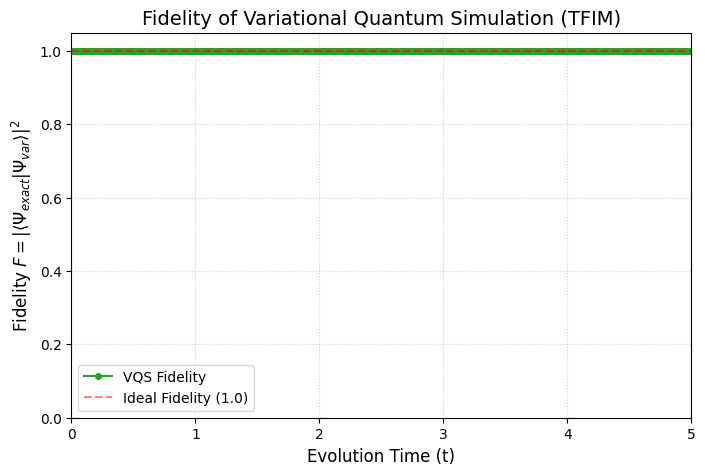

In [57]:
print(fidelities_novqs[-1])
plot_fidelity(time_points, fidelities_novqs)

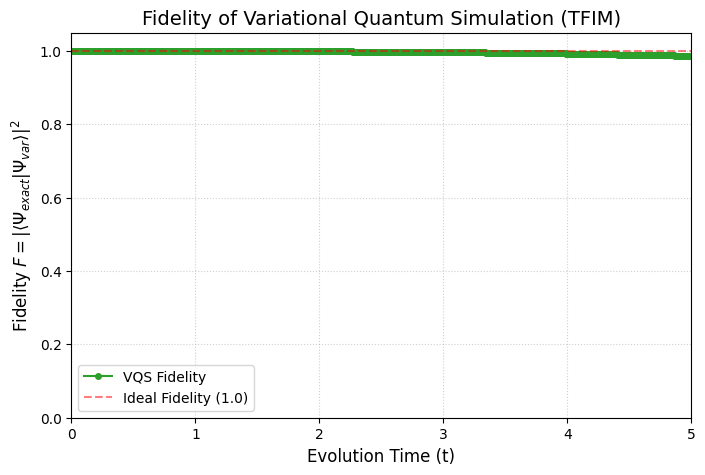

0.9866444833068658


In [46]:
import matplotlib.pyplot as plt

def plot_fidelity(time_points, fidelities):
    plt.figure(figsize=(8, 5), dpi=100)
    
    # Plot the fidelity curve
    plt.plot(time_points, fidelities, 'o-', color='#2ca02c', label='VQS Fidelity', markersize=4)
    
    # Plot the ideal reference line (Fidelity = 1)
    plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Ideal Fidelity (1.0)')
    
    # Set the axis limits
    plt.ylim(0, 1.05)  # Extend slightly above 1.0 to keep the topmost points visible
    plt.xlim(time_points[0], time_points[-1])
    
    # Add axis labels and a title
    plt.xlabel('Evolution Time (t)', fontsize=12)
    plt.ylabel('Fidelity $F = |\\langle \\Psi_{exact} | \\Psi_{var} \\rangle|^2$', fontsize=12)
    plt.title('Fidelity of Variational Quantum Simulation (TFIM)', fontsize=14)
    
    plt.grid(True, which='both', linestyle=':', alpha=0.6)
    plt.legend(loc='lower left')
    
    plt.show()

# Call the plotting function
distance = 2.0
init_state = 'HF' 
init_dist = 'Perturbation' 
T = 5.0
Ns = 6
file_path = f"data/NOVQS-RTE-fidelities-{model_name}-dist={distance}-Nq={Nq}-T={T}-dt={dt}-L={n_layers}-B={n_blocks}-Ns={Ns}-{init_state}-{init_dist}.npy"
data = jnp.load(file_path, allow_pickle=True).item()
fidelities_novqs = data['fidelities']
time_points = data['time_points']

plot_fidelity(time_points, fidelities_novqs)
print(fidelities_novqs[-1])

# Plot

## H4 Chain

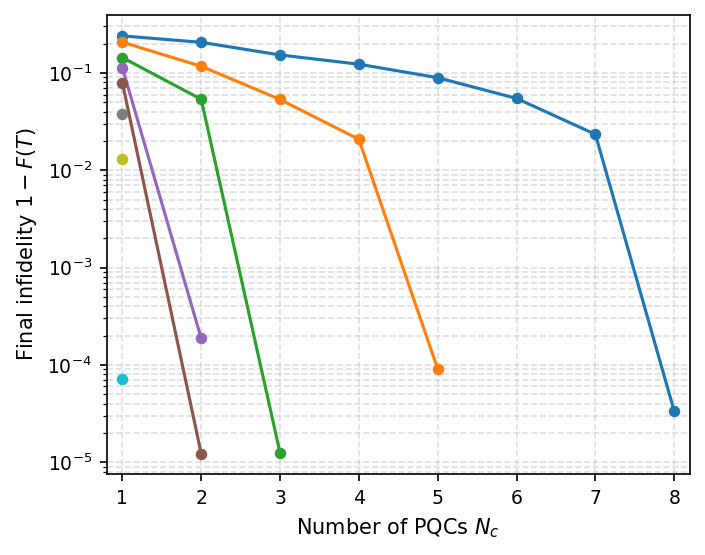

In [2]:
from pathlib import Path

def load_final_fidelity(file_path):
    """Load a file and return the fidelity and infidelity at the final time point."""
    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    data = np.load(file_path, allow_pickle=True).item()
    fidelities = np.asarray(data["fidelities"]).reshape(-1)

    final_fidelity = float(np.real(fidelities[-1]))
    final_infidelity = 1.0 - final_fidelity

    return final_fidelity, final_infidelity


# --------------------------------------------------
# 1. Data configurations to load
# --------------------------------------------------

# Standard VQS is treated as Ns=1
vqs_B_values = range(1, 9)

# NOVQS (B, Ns) configurations
novqs_B_Ns_pairs = [
    (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2),
    (2, 5), (2, 4), (2, 3), (2, 2),
    (3, 3), (3, 2),
    (4, 2),
    (5, 2),
]

model_name = 'H4Chain'
distance = 2.0
Nq = 8
T = 5.0
dt = 0.005
n_layers = Nq // 2
init_state = 'US'
init_dist = 'Zeros'

# --------------------------------------------------
# 2. Extract the final fidelity and infidelity
# --------------------------------------------------

# plot_data[B] = [(Ns, final_infidelity), ...]
plot_data = {B: [] for B in vqs_B_values}

# Load standard VQS data, corresponding to Ns=1
for B in vqs_B_values:

    file_path = (
        f"data/VQS-RTE-fidelities-"
        f"{model_name}-dist={distance}-Nq={Nq}-T={T}-dt={dt}-"
        f"L={n_layers}-B={B}-{init_state}-{init_dist}.npy"
    )

    final_fidelity, final_infidelity = load_final_fidelity(file_path)

    plot_data[B].append((1, final_infidelity))



# Load NOVQS data
for B, Ns in novqs_B_Ns_pairs:

    file_path = (
        f"data/NOVQS-RTE-fidelities-"
        f"{model_name}-dist={distance}-Nq={Nq}-T={T}-dt={dt}-"
        f"L={n_layers}-B={B}-Ns={Ns}-{init_state}-{init_dist}.npy"
    )

    final_fidelity, final_infidelity = load_final_fidelity(file_path)

    plot_data[B].append((Ns, final_infidelity))


# --------------------------------------------------
# 4. Plot
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(4.8, 3.8), dpi=150)

colors = plt.colormaps["tab10"](
    np.linspace(0, 1, len(vqs_B_values))
)

for index, B in enumerate(vqs_B_values):

    points = sorted(plot_data[B], key=lambda x: x[0])

    Ns_values = [point[0] for point in points]
    infidelity_values = [point[1] for point in points]

    ax.plot(
        Ns_values,
        infidelity_values,
        color=colors[index],
        marker="o",
        markersize=4.5,
        linewidth=1.5,
        label=fr"$N_l={B}$",
    )


ax.set_xlabel(r"Number of PQCs $N_c$", fontsize=10)
ax.set_ylabel(r"Final infidelity $1-F(T)$", fontsize=10)

ax.set_xticks(range(1, 9))
ax.set_xlim(0.8, 8.2)

# Use a logarithmic scale if the errors span several orders of magnitude
ax.set_yscale("log")

ax.tick_params(axis="both", which="major", labelsize=9)
ax.grid(True, which="both", linestyle="--", alpha=0.4)

#ax.legend(fontsize=8, ncol=1, frameon=True, loc="lower center", bbox_to_anchor=(0.75, 0.))

plt.tight_layout()

#plt.savefig(f"fig/{model_name}-final-infidelity-vs-Nc.pdf", bbox_inches="tight")

plt.show()

## H5 Chain

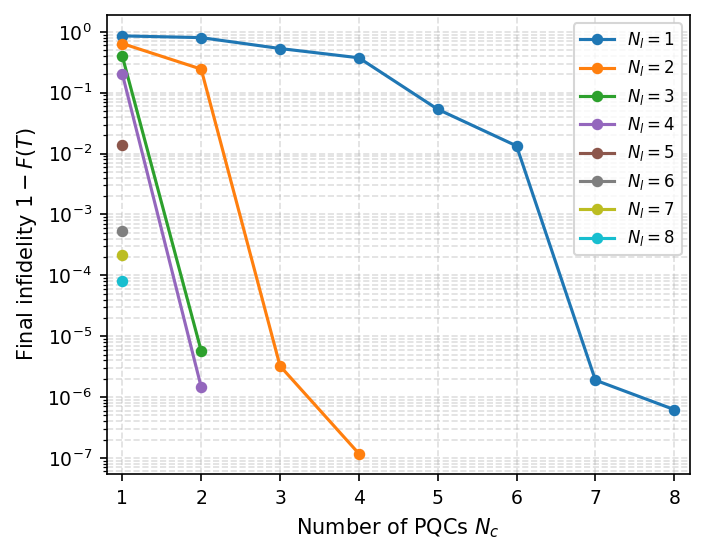

In [3]:
from pathlib import Path

def load_final_fidelity(file_path):
    """Load a file and return the fidelity and infidelity at the final time point."""
    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    data = np.load(file_path, allow_pickle=True).item()
    fidelities = np.asarray(data["fidelities"]).reshape(-1)

    final_fidelity = float(np.real(fidelities[-1]))
    final_infidelity = 1.0 - final_fidelity

    return final_fidelity, final_infidelity


# --------------------------------------------------
# 1. Data configurations to load
# --------------------------------------------------

# Standard VQS is treated as Ns=1
vqs_B_values = range(1, 9)

# NOVQS (B, Ns) configurations
novqs_B_Ns_pairs = [
    (1, 8), (1, 7), (1, 6), (1, 5), (1, 4), (1, 3), (1, 2),
    (2, 4), (2, 3), (2, 2),
    (3, 2),
    (4, 2)
]

model_name = 'H5Chain'
distance = 2.0
Nq = 10
T = 5.0
dt = 0.005
n_layers = Nq // 2
init_state = 'HF'
init_dist = 'Perturbation'

# --------------------------------------------------
# 2. Extract the final fidelity and infidelity
# --------------------------------------------------

# plot_data[B] = [(Ns, final_infidelity), ...]
plot_data = {B: [] for B in vqs_B_values}


# Load standard VQS data, corresponding to Ns=1
for B in vqs_B_values:

    file_path = (
        f"data/VQS-RTE-fidelities-"
        f"{model_name}-dist={distance}-Nq={Nq}-T={T}-dt={dt}-"
        f"L={n_layers}-B={B}-{init_state}-{init_dist}.npy"
    )

    final_fidelity, final_infidelity = load_final_fidelity(file_path)

    plot_data[B].append((1, final_infidelity))



# Load NOVQS data
for B, Ns in novqs_B_Ns_pairs:

    file_path = (
        f"data/NOVQS-RTE-fidelities-"
        f"{model_name}-dist={distance}-Nq={Nq}-T={T}-dt={dt}-"
        f"L={n_layers}-B={B}-Ns={Ns}-{init_state}-{init_dist}.npy"
    )

    final_fidelity, final_infidelity = load_final_fidelity(file_path)

    plot_data[B].append((Ns, final_infidelity))


# --------------------------------------------------
# 4. Plot
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(4.8, 3.8), dpi=150)

colors = plt.colormaps["tab10"](
    np.linspace(0, 1, len(vqs_B_values))
)

for index, B in enumerate(vqs_B_values):

    points = sorted(plot_data[B], key=lambda x: x[0])

    Ns_values = [point[0] for point in points]
    infidelity_values = [point[1] for point in points]

    ax.plot(
        Ns_values,
        infidelity_values,
        color=colors[index],
        marker="o",
        markersize=4.5,
        linewidth=1.5,
        label=fr"$N_l={B}$",
    )


ax.set_xlabel(r"Number of PQCs $N_c$", fontsize=10)
ax.set_ylabel(r"Final infidelity $1-F(T)$", fontsize=10)

ax.set_xticks(range(1, 9))
ax.set_xlim(0.8, 8.2)

# Use a logarithmic scale if the errors span several orders of magnitude
ax.set_yscale("log")

ax.tick_params(axis="both", which="major", labelsize=9)
ax.grid(True, which="both", linestyle="--", alpha=0.4)

ax.legend(
    fontsize=8,
    ncol=1,
    frameon=True,
    loc="upper right",
)

plt.tight_layout()

#plt.savefig(f"fig/{model_name}-final-infidelity-vs-Nc.pdf", bbox_inches="tight")

plt.show()